In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


# RandomizedSearch with Random Over Sampler

## Important Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report
import joblib
import os

## Sentinel-2

### Data Loading

In [ ]:
save_dir = "/content/drive/MyDrive/Thesis/Trained_models/"
file_path = "/content/drive/MyDrive/Thesis/Train_data/s2_with_veg_data.csv"

print("Loading data...")
df = pd.read_csv(file_path)
print("Data is loaded")


print("\nData preparation...")

df.drop(columns=["height", "stock_per_ha", "basal_area", "poly_id", "S2_Date"], axis=1, inplace=True)

df1 = df.loc[df["age"] != 5]

y = df1["age"] - 1
X = df1.drop(columns="age", axis=1)

# Split data into Train, Validation, and Test sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

print(f"\nDatasets are read! X_train shape: {X_train.shape}, X_test shape: {X_test.shape}, X_val shape: {X_val.shape}")

Loading data...
Data is loaded

Data preparation...

Datasets are read! X_train shape: (284286, 52), X_test shape: (50169, 52), X_val shape: (59022, 52)


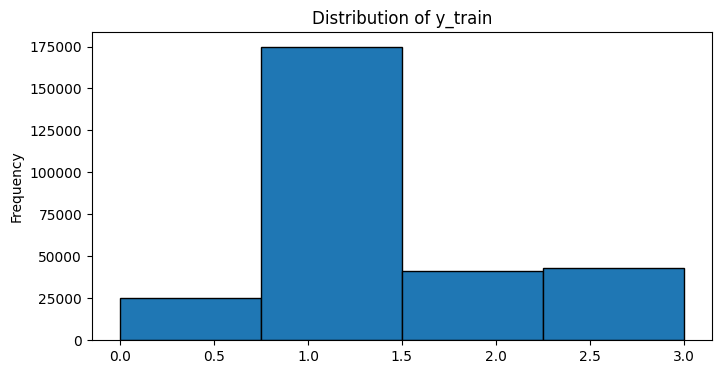

In [ ]:
# Plot target distribution
plt.figure(figsize=(8, 4))
y_train.plot.hist(bins=len(y_train.unique()), edgecolor='black')
plt.title("Distribution of y_train")
plt.show()

###RandomizedSearch

In [ ]:
print("\nStarting Hyperparameter Tuning with RandomizedSearchCV...")

# =========================================================
# 1. XGBClassifier Pipeline & Tuning
# =========================================================
pipeline_xgb = ImbPipeline([
    ("oversample", RandomOverSampler(sampling_strategy="auto", random_state=42)),
    ("classifier", XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        tree_method='hist',
        device="cuda"
    ))
])

# Expanded parameter grid for XGBoost
# param_distributions_xgb = {
#     'classifier__n_estimators': [200, 500, 1000, 2000],
#     'classifier__max_depth': [5, 7, 9, 11, 15],
#     'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
#     'classifier__subsample': [0.6, 0.8, 1.0],
#     'classifier__colsample_bytree': [0.6, 0.8, 1.0],
#     'classifier__min_child_weight': [1, 3, 5, 7], # Critical for preventing minority class overfitting
#     'classifier__gamma': [0, 0.1, 0.5, 1.0]       # Adds regularization
# }
# Best Params
#{'classifier__subsample': 0.6, 'classifier__n_estimators': 1000, 'classifier__min_child_weight': 7, 'classifier__max_depth': 11, 'classifier__learning_rate': 0.05, 'classifier__gamma': 1.0, 'classifier__colsample_bytree': 0.8}

param_distributions_xgb = {
    'classifier__n_estimators': [1000],
    'classifier__max_depth': [11],
    'classifier__learning_rate': [0.05],
    'classifier__subsample': [0.6],
    'classifier__colsample_bytree': [0.8],
    'classifier__min_child_weight': [7], # Critical for preventing minority class overfitting
    'classifier__gamma': [1.0]       # Adds regularization
}

search_xgb = RandomizedSearchCV(
    estimator=pipeline_xgb,
    param_distributions=param_distributions_xgb,
    # n_iter=200,         # Tests 200 random combinations (Utilizing the strong server)
    scoring='f1_macro',
    n_jobs=1,          # Keep at 1 so GPU VRAM doesn't crash from overlapping jobs
    cv=5,              # 5-fold cross validation for academic rigor
    verbose=2          # Set to 2 to see more detailed progress
)

print("Training XGBoost Pipeline (GPU Accelerated)...")
search_xgb.fit(X_train, y_train)

print("Best Parameters XGB: ", search_xgb.best_params_)
XGBmodel_age = search_xgb.best_estimator_


Starting Hyperparameter Tuning with RandomizedSearchCV...
Training XGBoost Pipeline (GPU Accelerated)...
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [10:06:03] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END classifier__colsample_bytree=0.8, classifier__gamma=1.0, classifier__learning_rate=0.05, classifier__max_depth=11, classifier__min_child_weight=7, classifier__n_estimators=1000, classifier__subsample=0.6; total time=  55.2s
[CV] END classifier__colsample_bytree=0.8, classifier__gamma=1.0, classifier__learning_rate=0.05, classifier__max_depth=11, classifier__min_child_weight=7, classifier__n_estimators=1000, classifier__subsample=0.6; total time=  54.9s
[CV] END classifier__colsample_bytree=0.8, classifier__gamma=1.0, classifier__learning_rate=0.05, classifier__max_depth=11, classifier__min_child_weight=7, classifier__n_estimators=1000, classifier__subsample=0.6; total time=  54.5s
[CV] END classifier__colsample_bytree=0.8, classifier__gamma=1.0, classifier__learning_rate=0.05, classifier__max_depth=11, classifier__min_child_weight=7, classifier__n_estimators=1000, classifier__subsample=0.6; total time=  55.1s
[CV] END classifier__colsample_bytree=0.8, classifier__gamma=1.0, cl

**Best Params**

In [ ]:
# #Best Parameters XGB:
#  {'classifier__subsample': 0.6,
# 'classifier__n_estimators': 1000,
# 'classifier__min_child_weight': 7,
# 'classifier__max_depth': 11,
# 'classifier__learning_rate': 0.05,
# 'classifier__gamma': 1.0,
# 'classifier__colsample_bytree': 0.8}


### Save Models

##Alpha Earth Foundation + Sentinel-2

### Data Loading

In [ ]:
save_dir = "/content/drive/MyDrive/Thesis/Trained_models/"
file_path = "/content/drive/MyDrive/Thesis/Train_data/s2_aef_with_veg_data.csv"

print("Loading data...")
df = pd.read_csv(file_path)
print("Data is loaded")


print("\nData preparation...")

df.drop(columns=["height", "stock_per_ha", "basal_area", "poly_id", "S2_Date"], axis=1, inplace=True)

df1 = df.loc[df["age"] != 5].dropna()

y = df1["age"] - 1
X = df1.drop(columns="age", axis=1)

# Split data into Train, Validation, and Test sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

print(f"\nDatasets are read! X_train shape: {X_train.shape}, X_test shape: {X_test.shape}, X_val shape: {X_val.shape}")

Loading data...
Data is loaded

Data preparation...

Datasets are read! X_train shape: (284117, 308), X_test shape: (50139, 308), X_val shape: (58987, 308)


In [ ]:
import gc
del df, df1, X, y

gc.collect()

0

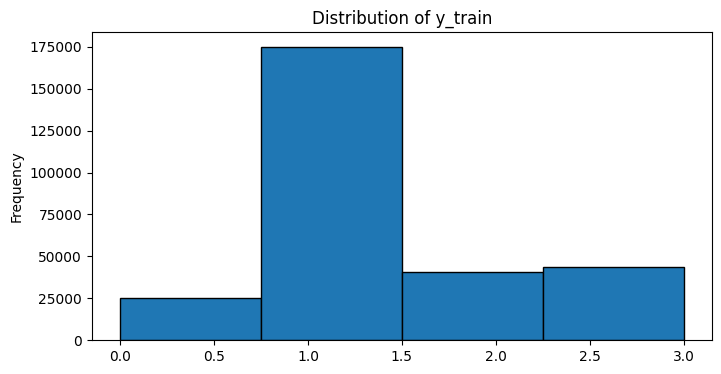

In [ ]:
# Plot target distribution
plt.figure(figsize=(8, 4))
y_train.plot.hist(bins=len(y_train.unique()), edgecolor='black')
plt.title("Distribution of y_train")
plt.show()

### RandomizedSearch

In [ ]:
print("\nStarting Hyperparameter Tuning with RandomizedSearchCV...")

# =========================================================
# 1. XGBClassifier Pipeline & Tuning
# =========================================================
pipeline_xgb = ImbPipeline([
    ("oversample", RandomOverSampler(sampling_strategy="auto", random_state=42)),
    ("classifier", XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        tree_method='hist',
        device="cuda"
    ))
])

# Expanded parameter grid for XGBoost
param_distributions_xgb = {
    'classifier__n_estimators': [200, 500, 1000, 2000],
    'classifier__max_depth': [5, 7, 9, 11, 15],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0],
    'classifier__min_child_weight': [1, 3, 5, 7], # Critical for preventing minority class overfitting
    'classifier__gamma': [0, 0.1, 0.5, 1.0]       # Adds regularization
}

search_xgb = RandomizedSearchCV(
    estimator=pipeline_xgb,
    param_distributions=param_distributions_xgb,
    n_iter=200,         # Tests 200 random combinations (Utilizing the strong server)
    scoring='f1_macro',
    n_jobs=5,          # Keep at 1 so GPU VRAM doesn't crash from overlapping jobs
    cv=5,              # 5-fold cross validation for academic rigor
    verbose=2          # Set to 2 to see more detailed progress
)

print("Training XGBoost Pipeline (GPU Accelerated)...")
search_xgb.fit(X_train, y_train)

print("Best Parameters XGB: ", search_xgb.best_params_)
XGBmodel_age = search_xgb.best_estimator_


Starting Hyperparameter Tuning with RandomizedSearchCV...
Training XGBoost Pipeline (GPU Accelerated)...
Fitting 5 folds for each of 200 candidates, totalling 1000 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters XGB:  {'classifier__subsample': 0.6, 'classifier__n_estimators': 2000, 'classifier__min_child_weight': 1, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.2, 'classifier__gamma': 0, 'classifier__colsample_bytree': 0.8}


**Best Params**

In [ ]:
# Best Parameters XGB:  {'classifier__subsample': 0.6, 'classifier__n_estimators': 2000, 'classifier__min_child_weight': 1, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.2, 'classifier__gamma': 0, 'classifier__colsample_bytree': 0.8}